# Aberrated Sample Holography

This notebook simulates off-axis electron holography with controllable aberrations and explores how astigmatism influences the reconstructed phase.

## Environment Setup

Configure numerical precision, plotting backends, and import the building blocks needed for ray tracing, hologram evaluation, and Libertem reconstruction utilities.

In [4]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.4' 

%matplotlib widget

import jax
import matplotlib.pyplot as plt
import numpy as np

from temgym_core.components import Detector
from temgym_core.gaussian import (
    run_to_end_vmapped, 
    square_input_wave,
    MagneticPhaseSample,
    InterpolatedSample2D,
    KrivanekLens, 
    DistortedLens, 
    Biprism,
) 
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.transfer_matrices import calculate_z1_and_z2_from_M_and_f
from temgym_core.constants import energy2wavelength
from temgym_core.aberrations import KrivanekCoeffs
from temgym_core.plotting import plot_model, PlotParams
from temgym_core.utils import make_tilted_uniform_cube, project_phase_along_z

from libertem_holo.base.reconstr import reconstruct_frame, phase_unwrap
from libertem_holo.base.utils import HoloParams
from libertem_holo.base.align import get_slice_fft
from libertem_holo.base.filters import clipped
from libertem_holo.base.utils import remove_phase_ramp

jax.config.update("jax_enable_x64", True)

## Parameterized TEM and Holography Model

`run_model` encapsulates the microscope optics, biprism, sample, and detector definition so we can reuse the same pipeline for multiple aberration settings.

In [5]:
def run_model(input_window_width_m=1e-6,
              fringe_spacing=6e-9, # Desired fringe spacing in metres
              num_pixels=1024, # Number of pixels in detector
              voltage_eV=200e3,
              input_cube_xy=(0.0, 0.0),
              input_cube_x_tilt=0.0,  # radians
              input_cube_side_length=50e-9,  # metres
              obj_focal_length=2.5e-3,  # 2.5 mm
              obj_magnification=-1, # Must be negative
              projector_focal_length=5e-3,  # 5 mm
              projector_magnification=-40_000, # Must be negative
              defocus=0.0,
              C12_aberration=0.0,
              C21_aberration=0.0,
              isotropic_distortion=0.0,
              anisotropic_distortion=0.0,
              beam_waist=2e-9,
              overlap_factor = 1.6,
              detector_rotation=0.0,
              plot_input_field=False,
              plot_output_field=True,
              plot_output_rays=False,
              plot_ray_diagram=False):

    # Create input field
    wavelength = energy2wavelength(voltage_eV)
    k = 2 * np.pi / wavelength
    pixel_size = input_window_width_m / num_pixels
    total_mag = projector_magnification

    input_grid = Detector(
    z=defocus,
    pixel_size=(pixel_size, pixel_size),
    shape=(num_pixels, num_pixels),
    )

    rays_in = square_input_wave(voltage=voltage_eV,
                                aperture_length=input_window_width_m,
                                waist=beam_waist,
                                overlap_factor=overlap_factor,
                                z0=defocus)
    
    simulation_side_length = input_cube_side_length * 2
    cube_fraction = input_cube_side_length / simulation_side_length
    sample_fields, sample_x_coords, sample_y_coords, sample_z_coords = make_tilted_uniform_cube(
        tilt_x=input_cube_x_tilt,
        L=simulation_side_length,
        cube_fraction=cube_fraction,
        x0=input_cube_xy[0],
        y0=input_cube_xy[1],
        B0=0.2,
        V0=0.01,
        amplitude_dampening=0.5,  # 50% amplitude inside the cube
    )
    sample_amp, sample_phase_shift = project_phase_along_z(
        fields=sample_fields,
        z_coords=sample_z_coords,
        voltage=voltage_eV,
    )
    sample = sample_amp * np.exp(1j * sample_phase_shift / k)

    sample = InterpolatedSample2D.from_array(sample=sample, x_coords=sample_x_coords, y_coords=sample_y_coords, z=0.0)
    rays_after_sample = run_to_end_vmapped(rays_in, (sample,))
    print(f"Number of input Rays: {len(rays_after_sample.x)}")

    if plot_input_field:
        input_field = evaluate_gaussians_gpu_kernel_wrapper(rays_after_sample, input_grid).block_until_ready()

        fig, axs = plt.subplots(1, 2)
        axs[0].imshow(np.abs(input_field), extent=input_grid.extent, cmap='inferno')
        axs[0].set_title('Input Field Amplitude')
        axs[1].imshow(np.angle(input_field), extent=input_grid.extent, cmap='twilight')
        axs[1].set_title('Input Field Phase')
        plt.tight_layout()

    # Set up Optical System - z1 = object plane distance from objective lens to sample - it's negative since the sample is before the lens
    # z2 = distance from objective lens to it's image plane
    z1, z2 = calculate_z1_and_z2_from_M_and_f(
        M=obj_magnification,
        f=obj_focal_length,
    )
    # z3 = object plane distance from projector lens to it's image plane - again it's negative since the image plane is before the lens
    # z4 = distance fromt projector lens to detector
    z3, z4 = calculate_z1_and_z2_from_M_and_f(
        M=projector_magnification,
        f=projector_focal_length,
    )
    z1, z2, z3, z4 = map(abs, (z1, z2, z3, z4))  # Ensure distances are positive

    # Calculate biprism strength needed for desired fringe spacing
    # Biprism is placed halfway between the objective lens focal plane (where the source is)
    # and it's image plane, where the friges will be observed.
    biprism_z = z1 + obj_focal_length + ((z1 + z2) - (z1 + obj_focal_length)) / 2 
    a = biprism_z - (z1 + obj_focal_length)
    b = ((z1 + z2) - biprism_z)

    # Quick assert to check distances add up
    L = a + b
    assert L == z1 + z2 - (z1 + obj_focal_length)

    b_def = wavelength * (a + b) / (2 * fringe_spacing * a)

    aberration_coefficients = KrivanekCoeffs(
        C12=C12_aberration,
        phi12=0.0,  # 45 degrees
        C21=C21_aberration,
    )
    objective_lens = KrivanekLens(z=z1, focal_length=obj_focal_length, coeffs=aberration_coefficients)
    biprism = Biprism(z=biprism_z, strength=b_def, width=1e-11)
    projector_lens = DistortedLens(z=z1+z2+z3, object_plane_dist=z3, focal_length=projector_focal_length,
                                    IsoDist=isotropic_distortion, AnisoDist=anisotropic_distortion)
    detector = Detector(
        z=z1 + z2 + z3 + z4,
        pixel_size=(pixel_size * abs(projector_magnification) / 3, pixel_size * abs(projector_magnification) / 3),
        shape=(num_pixels, num_pixels),
        rotation=detector_rotation
    )
    extent = detector.extent
    det_xy_coords_1d = detector.coords_1d

    rays_out_with_sample = run_to_end_vmapped(rays_in, (sample, objective_lens, biprism, projector_lens, detector))
    rays_out_without_sample = run_to_end_vmapped(rays_in, (objective_lens, biprism, projector_lens, detector))
    output_holo_with_sample = evaluate_gaussians_gpu_kernel_wrapper(rays_out_with_sample, detector).block_until_ready()
    output_holo_without_sample = evaluate_gaussians_gpu_kernel_wrapper(rays_out_without_sample, detector).block_until_ready()

    if plot_output_field:
        fig, axs = plt.subplots(1, 2)
        axs[0].imshow(np.abs(output_holo_with_sample) ** 2, cmap='gray')
        axs[0].set_title('Hologram Intensity With Sample')
        axs[1].imshow(np.abs(output_holo_without_sample) ** 2, cmap='gray')
        axs[1].set_title('Hologram Intensity Without Sample')
        plt.tight_layout()
    if plot_output_rays:
        axs[0].plot(rays_out_with_sample.x, rays_out_with_sample.y, 'r.', markersize=5.0, alpha=1.0)
        axs[1].plot(rays_out_without_sample.x, rays_out_without_sample.y, 'r.', markersize=5.0, alpha=1.0)

    if plot_ray_diagram:
        plot_model(
            components=[sample, objective_lens, biprism, projector_lens, detector],
            rays=rays_in[::10000],
            plot_params=PlotParams(
                figsize=(10, 6),
            ),
        )

    return output_holo_with_sample, output_holo_without_sample, extent, det_xy_coords_1d

## Baseline Simulation Run

The next cell defines a reusable dictionary of simulation parameters and executes the model once to generate holograms with the default aberration settings.

Number of input Rays: 640000


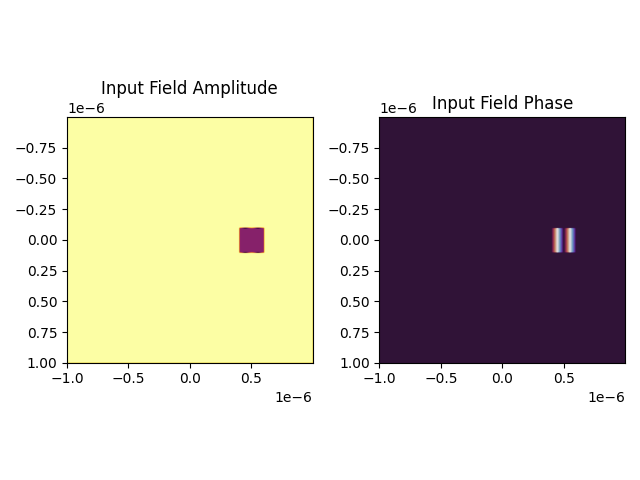

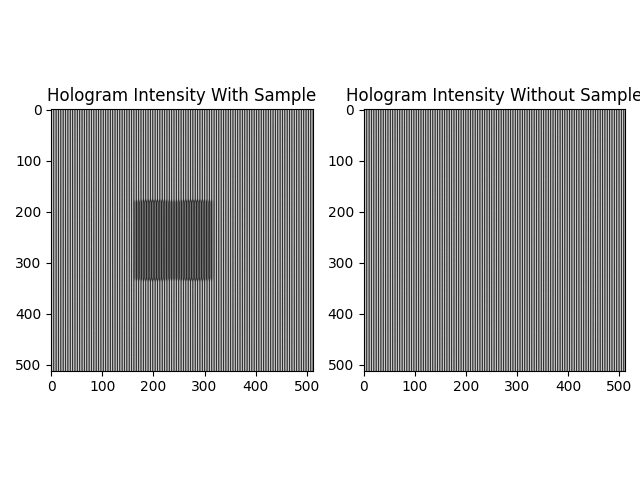

In [6]:

base_simulation_kwargs = dict(
    voltage_eV=200e3,
    input_window_width_m=2000e-9,
    fringe_spacing=6e-9,
    num_pixels=512,
    beam_waist=4e-9,
    input_cube_xy=(0.5e-6, 0.0e-6),
    input_cube_side_length=100e-9,
    input_cube_x_tilt=np.deg2rad(0),
    obj_magnification=-1,
    C12_aberration=0.0,
    C21_aberration=0.0,
    isotropic_distortion=0.0,
    anisotropic_distortion=0.0,
    plot_input_field=True,
    plot_output_field=True,
    plot_output_rays=False,
    plot_ray_diagram=False,
    detector_rotation=0.0,
)

output_holo_with_sample, output_holo_without_sample, extent, det_xy_coords_1d = run_model(
    **base_simulation_kwargs
)


## Reconstruction Utilities

A small helper prepares the Libertem hologram reconstruction so we can consistently recover the exit wave amplitude and phase for any simulated hologram.

In [7]:

def reconstruct_wave_and_phase(hologram, out_shape=None, xp=np):
    """Reconstruct the exit wave and unwrap the phase in a reusable helper."""
    if out_shape is None:
        out_shape = hologram.shape

    holo_params = HoloParams.from_hologram(
        hologram=hologram,
        out_shape=out_shape,
        xp=xp,
    )
    slice_fft = get_slice_fft(sig_shape=hologram.shape, out_shape=out_shape)
    wave_obj = reconstruct_frame(
        frame=hologram,
        sb_pos=holo_params.sb_position,
        slice_fft=slice_fft,
        aperture=holo_params.aperture,
        xp=xp,
    )
    phase, _, _ = remove_phase_ramp(np.angle(wave_obj))
    return wave_obj, phase, holo_params


## Reconstruct Baseline Sample Wave

Convert the simulated hologram into the complex exit wave and unwrap its phase for the baseline configuration.

In [8]:

holo = np.abs(output_holo_with_sample) ** 2

wave_obj, phase_t, holo_params = reconstruct_wave_and_phase(
    hologram=holo,
)


## Visualize Baseline Reconstruction

Inspect the reconstructed amplitude and phase maps to confirm the simulation behaves as expected.

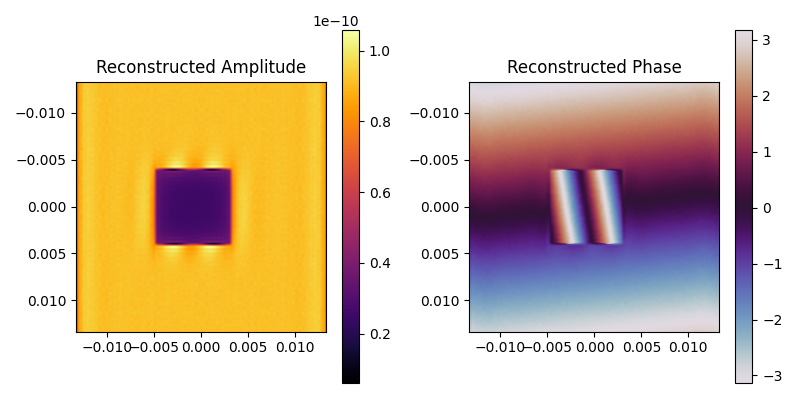

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
im0 = axs[0].imshow(np.abs(wave_obj), extent=extent, cmap='inferno')
axs[0].set_title('Reconstructed Amplitude')
fig.colorbar(im0, ax=axs[0])
im1 = axs[1].imshow(phase_t, cmap='twilight', extent=extent)
axs[1].set_title('Reconstructed Phase')
fig.colorbar(im1, ax=axs[1])
plt.tight_layout()

## Inspect Hologram Fourier Spectrum

View the hologram in reciprocal space to verify the sideband position used during reconstruction.

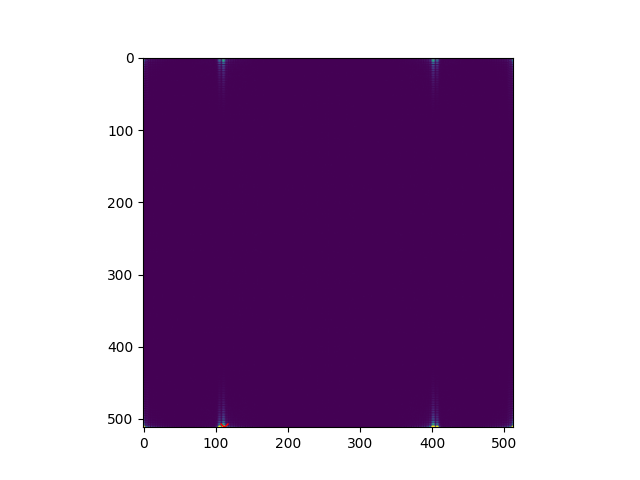

In [14]:
fft = np.fft.fft2(holo)
img = np.abs(fft)
plt.figure()
plt.imshow(img, vmin=np.min(clipped(img)), vmax=np.max(clipped(img)))
plt.plot(holo_params.sb_position[1],
         holo_params.sb_position[0], 'rx')

## Compare Astigmatism Impact

Generate two holograms with different C12 astigmatism strengths, reconstruct each, and store the phase maps for comparison.

Number of input Rays: 640000


/nobackup/dl277493/.pyenv/versions/JaxGym/lib/python3.12/site-packages/jax/_src/numpy/lax_numpy.py:5732: FutureWarning: None encountered in jnp.array(); this is currently treated as NaN. In the future this will result in an error.
  return array(a, dtype=dtype, copy=bool(copy), order=order, device=device)


Number of input Rays: 640000


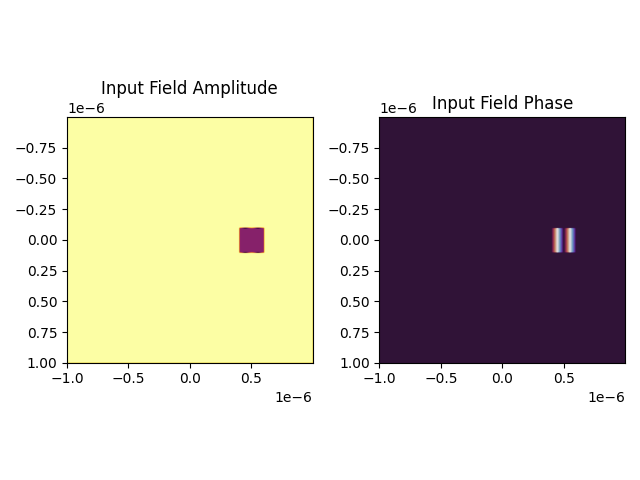

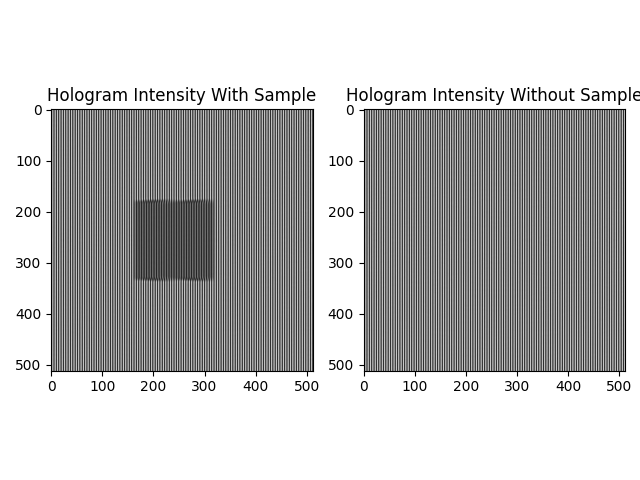

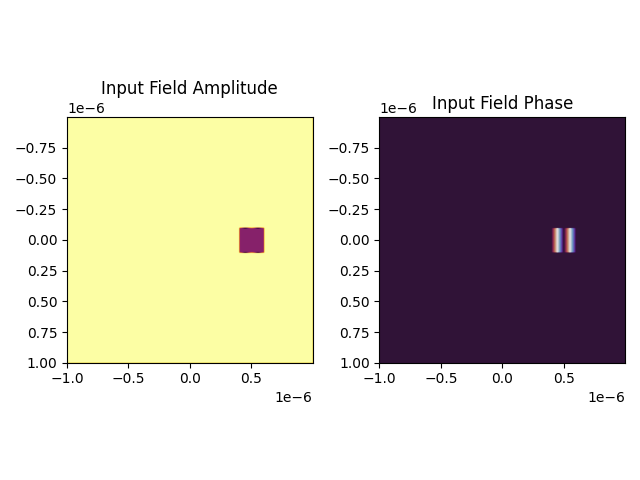

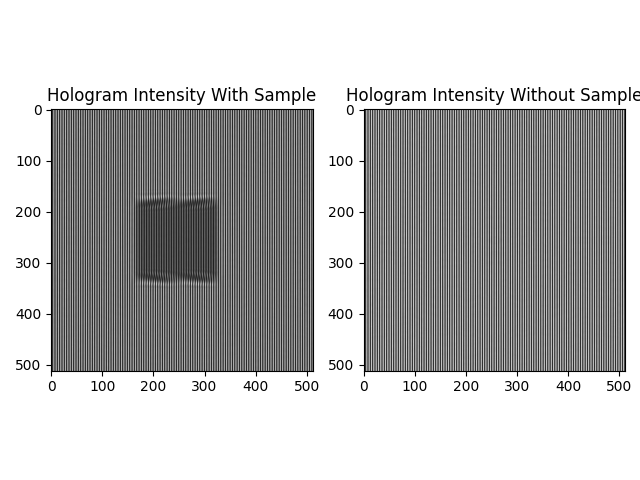

In [11]:

astigmatism_values = [5e-6, 2.5e-5]
phase_comparisons = []

for value in astigmatism_values:
    sim_kwargs = dict(base_simulation_kwargs)
    sim_kwargs['C12_aberration'] = value
    holo_with_sample, _, extent_comp, _ = run_model(**sim_kwargs)
    hologram = np.abs(holo_with_sample) ** 2
    _, phase_map, _ = reconstruct_wave_and_phase(
        hologram=hologram,
    )
    phase_comparisons.append(
        {
            'C12': value,
            'phase': phase_map,
            'extent': extent_comp,
        }
    )


### Plot Phase Profiles Side by Side

Visualize the reconstructed phase for both astigmatism settings to highlight how aberrations modify the phase profile.

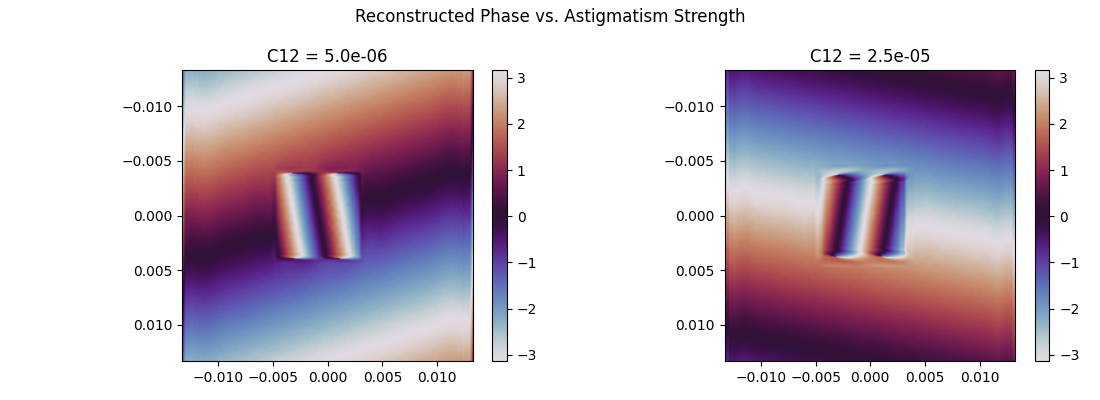

In [12]:

fig, axs = plt.subplots(1, len(phase_comparisons), figsize=(11, 4))
axs = np.atleast_1d(axs)

for ax, result in zip(axs, phase_comparisons):
    im = ax.imshow(result['phase'], extent=result['extent'], cmap='twilight')
    ax.set_title(f"C12 = {result['C12']:.1e}")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Reconstructed Phase vs. Astigmatism Strength')
plt.tight_layout()
